# TP 3 : Prétraitement de données et Analyse Exploratoire

Ce TP porte sur l'analyse, le prétraitement et l'exploration d'un jeu de données de voitures d'occasion.

## 1. Analyse de Forme

1. Importer les bibliothèques essentielles pour un projet de science de données (numpy, pandas, matplotlib, scikit-learn)
2. Inspecter l'ensemble des données (afficher les 5 premières lignes, les 5 dernières, et un échantillon de 7 observations)
3. Résumer la structure du DataFrame (type d'index, étiquettes de colonnes, types de données, valeurs manquantes)
4. Afficher la forme du DataFrame (nombre de lignes et de colonnes)
5. Décrire le DataFrame
6. Compter les lignes dupliquées et les valeurs manquantes

## 2. Prétraitement de la DataFrame

1. Traiter les valeurs manquantes
2. Convertir les colonnes numériques en types appropriés (ex : milage, price)
3. Créer une fonction pour calculer l'âge du véhicule et remplacer `model_year` par `age`
4. Transformer la colonne `transmission` en trois catégories (Automatic, Manual, Other)
5. Appliquer un OneHotEncoding sur `transmission`
6. Extraire la puissance (Horsepower) et la taille du cylindre (Engine_Sylinder) depuis la colonne `engine`
7. Inspecter et traiter à nouveau les valeurs manquantes
8. Continuer le nettoyage si nécessaire

## 3. Analyse Exploratoire (EDA)

1. BarPlot de la distribution des marques
2. Visualiser la variable cible (`price`) en fonction d'autres variables
3. Inspecter les relations entre variables (pairplot, matrice de corrélation)
4. Poursuivre l'analyse visuelle si besoin


In [1]:
# Import des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
df = pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [2]:
# Afficher les premières et dernières lignes, et un échantillon
print(df.head())
print(df.tail())
print(df.sample(7))

      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1  8-Speed Automatic        

In [3]:
# Infos sur le DataFrame
print(df.info())
print('Colonnes :', df.columns.tolist())
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
None
Colonnes : ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']
Valeurs manquantes par colonne :
brand             0
model             0
model_year        0
mil

In [4]:
# Forme du DataFrame
print(df.shape)

(4009, 12)


In [5]:
# Description simple
df.describe(include='all')

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,3413,39
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Lignes dupliquées et valeurs manquantes
print('Lignes dupliquées :', df.duplicated().sum())
print('Valeurs manquantes :', df.isnull().sum().sum())

Lignes dupliquées : 0
Valeurs manquantes : 879


# 2. Prétraitement de la DataFrame

In [7]:


# 1. Enlever les lignes où le prix est manquant
# (On garde que les voitures qui ont un prix)
df = df.dropna(subset=['price'])

# 2. Nettoyer les colonnes milage et price
# (On enlève les caractères et on convertit en nombre)
df['milage'] = df['milage'].str.replace(' mi.', '').str.replace(',', '').astype(float)
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

# 3. Créer l'âge du véhicule
# (On calcule l'âge à partir de l'année du modèle)
def get_age(year):
    try:
        return 2026 - int(year)
    except:
        return None
df['age'] = df['model_year'].apply(get_age)
df = df.drop('model_year', axis=1)

# 4. Simplifier la transmission
# (On classe en automatique, manuelle ou autre)
def simple_trans(x):
    x = str(x).lower()
    if 'auto' in x:
        return 'Automatic'
    elif 'man' in x:
        return 'Manual'
    else:
        return 'Other'
df['trans_simple'] = df['transmission'].apply(simple_trans)

# 5. OneHotEncoding sur transmission
# (On crée des colonnes 0/1 pour chaque type)
df = pd.get_dummies(df, columns=['trans_simple'])

# 6. Extraire puissance et cylindres depuis 'engine'
# (On récupère la puissance et le nombre de cylindres)
import re
def get_hp(x):
    m = re.search(r'(\d+(\.\d+)?)hp', str(x).lower())
    return float(m.group(1)) if m else None
def get_cyl(x):
    m = re.search(r'(\d+)[ -]?cylinder', str(x).lower())
    return int(m.group(1)) if m else None
df['horsepower'] = df['engine'].apply(get_hp)
df['cylinders'] = df['engine'].apply(get_cyl)

# 7. Vérifier les valeurs manquantes
print(df.isnull().sum())

brand                       0
model                       0
milage                      0
fuel_type                 170
engine                      0
transmission                0
ext_col                     0
int_col                     0
accident                  113
clean_title               596
price                       0
age                         0
trans_simple_Automatic      0
trans_simple_Manual         0
trans_simple_Other          0
horsepower                808
cylinders                 945
dtype: int64


# 3. Analyse Exploratoire (EDA)


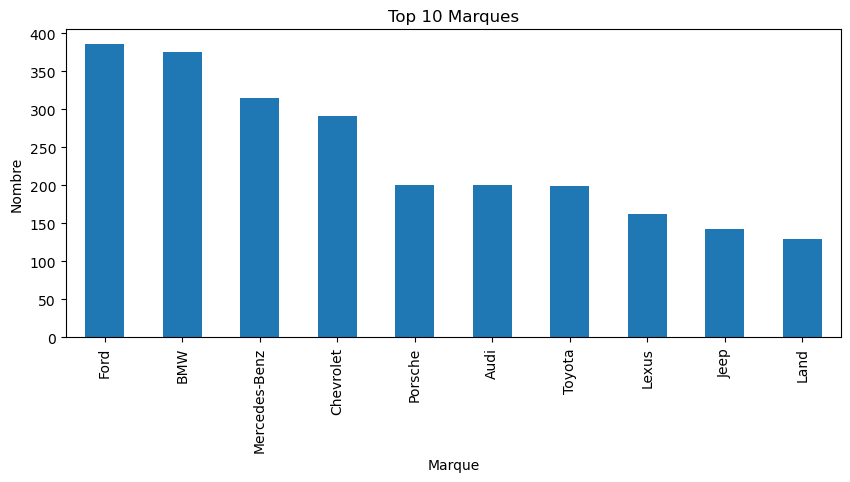

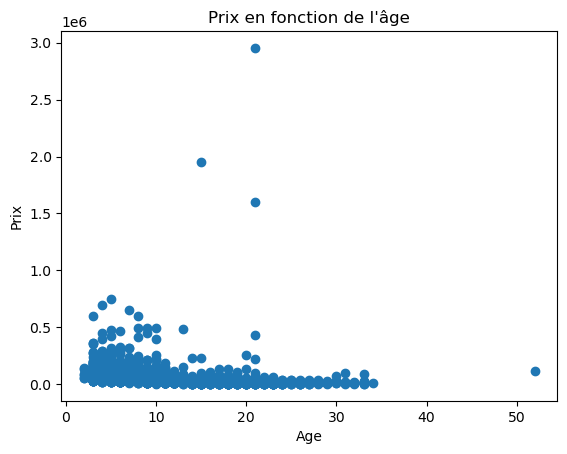

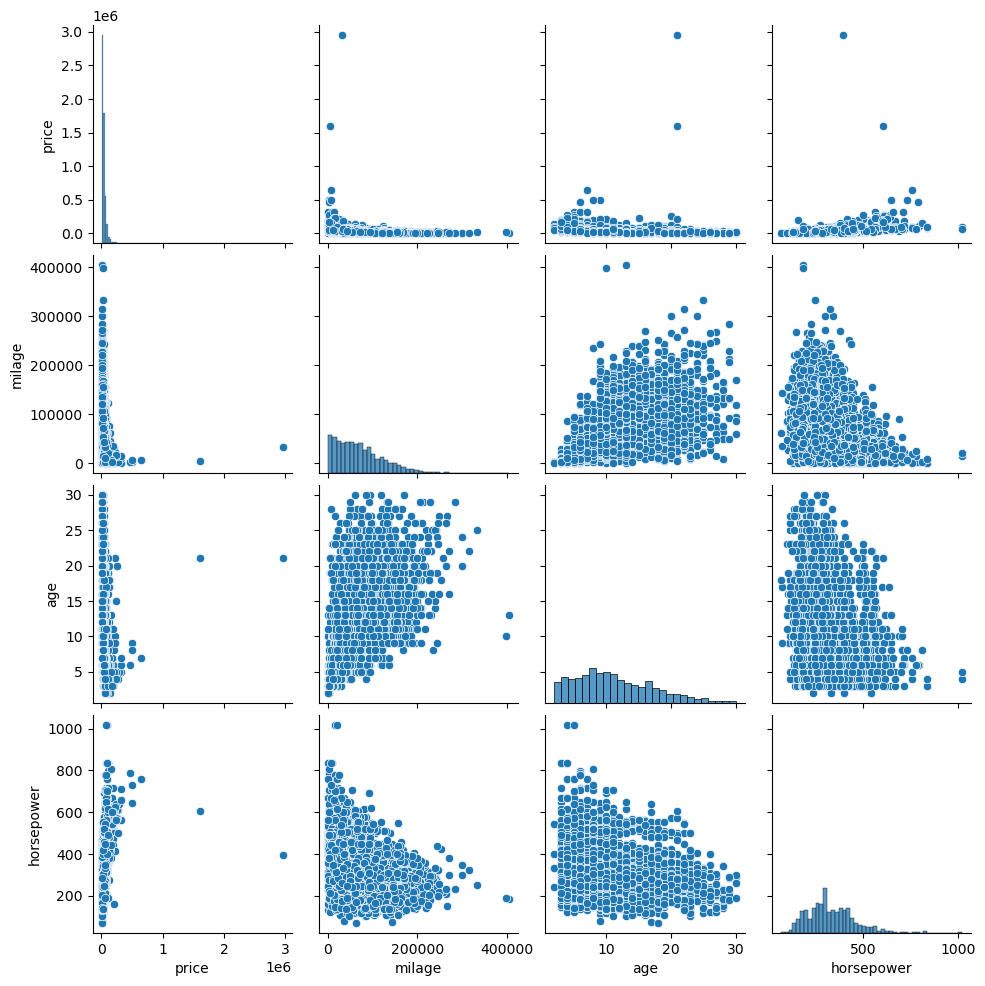

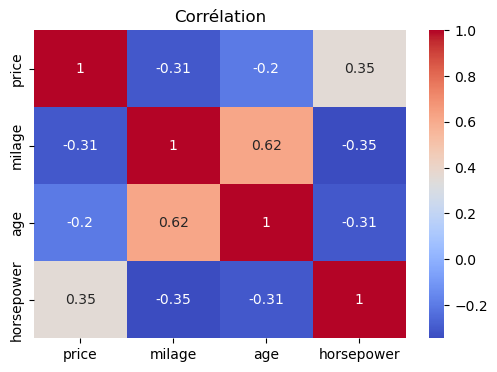

In [8]:

# 1. BarPlot de la distribution des marques
plt.figure(figsize=(10,4))
df['brand'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Marques')
plt.xlabel('Marque')
plt.ylabel('Nombre')
plt.show()

# 2. Visualiser le prix en fonction de l'âge
plt.scatter(df['age'], df['price'])
plt.xlabel('Age')
plt.ylabel('Prix')
plt.title("Prix en fonction de l'âge")
plt.show()

# 3. Pairplot et matrice de corrélation
# (On regarde les relations entre les variables principales)
sns.pairplot(df[['price', 'milage', 'age', 'horsepower']].dropna())
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df[['price', 'milage', 'age', 'horsepower']].corr(), annot=True, cmap='coolwarm')
plt.title('Corrélation')
plt.show()